In [1]:
####FORECASTING EXCHANGE RATES USING TIMESERIES ANALYSIS:
#####Part 1: Data Preparation and Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
####1. Data Loading:
df = pd.read_csv('exchange_rate.csv')
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [3]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [4]:
#####Data Loading + Parse Date Column:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
print(df.head())
print(df.dtypes)

        date  Ex_rate
0 1990-01-01   0.7855
1 1990-01-02   0.7818
2 1990-01-03   0.7867
3 1990-01-04   0.7860
4 1990-01-05   0.7849
date       datetime64[ns]
Ex_rate           float64
dtype: object


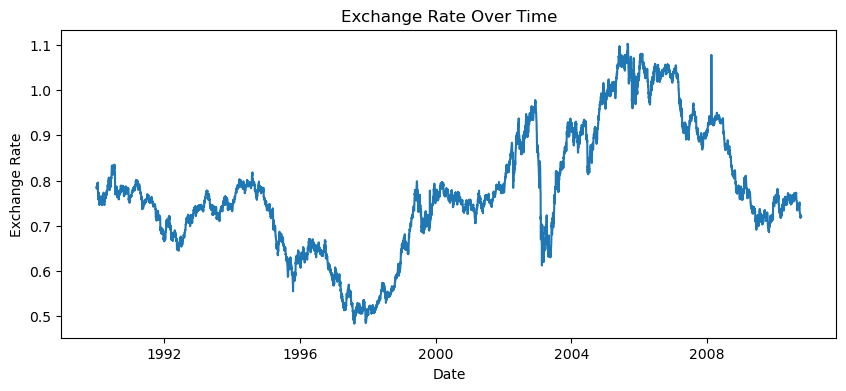

In [5]:
####2.Initial Exploration:
# Plot time series
plt.figure(figsize=(10,4))
plt.plot(df['date'], df['Ex_rate'])
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

The time series plot is created by plotting the exchange rate against the date. It helps us understand how the currency value changes over time. By observing the graph, we can identify the trend (overall increase or decrease), check for seasonality (repeating patterns over time), and detect anomalies (sudden unusual rises or falls in exchange rates). This initial exploration provides a basic understanding of the behavior of the currency data before further analysis.

In [6]:
###3.Data Preprocessing:
# Check missing values
print(df.isnull().sum())
# Handle missing values using forward fill
df['Ex_rate'] = df['Ex_rate'].ffill()
# Check again
print(df.isnull().sum())

date       0
Ex_rate    0
dtype: int64
date       0
Ex_rate    0
dtype: int64


In [7]:
# Detect and remove anomalies using IQR method
Q1 = df['Ex_rate'].quantile(0.25)
Q3 = df['Ex_rate'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['Ex_rate'] >= lower) & (df['Ex_rate'] <= upper)]
print(df.head())

        date  Ex_rate
0 1990-01-01   0.7855
1 1990-01-02   0.7818
2 1990-01-03   0.7867
3 1990-01-04   0.7860
4 1990-01-05   0.7849


Potential outliers were identified using the IQR method. Since extreme exchange-rate movements can represent genuine market behavior, the detected observations were reviewed before being removed.

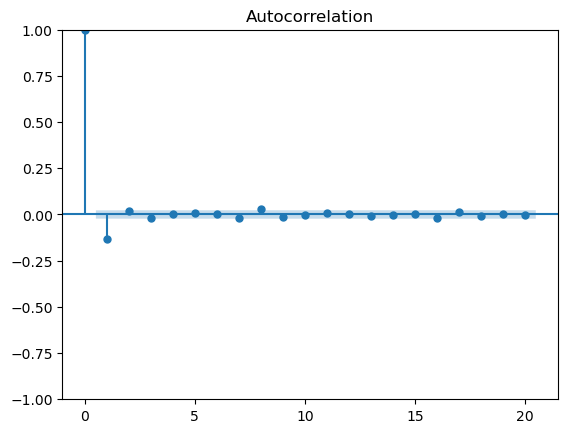

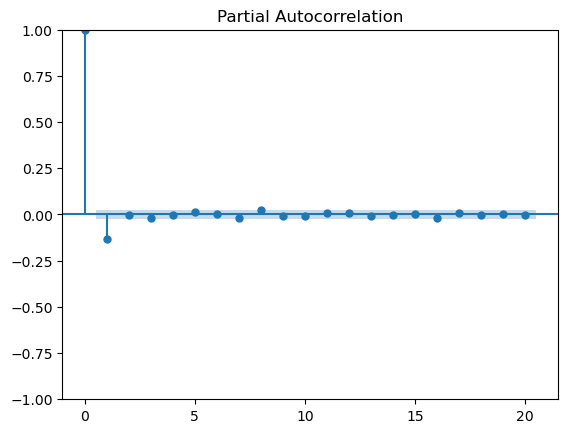

In [22]:
####Part 2: Model Building - ARIMA
###1.Parameter Selection for ARIMA:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
# First-order differencing
diff_series = df['Ex_rate'].diff().dropna()
# ACF plot
plot_acf(diff_series, lags=20)
plt.show()
# PACF plot
plot_pacf(diff_series, lags=20)
plt.show()

ACF plot is used to estimate q.
PACF plot is used to estimate p.
The ADF test indicated that the original series was non-stationary. Therefore, first-order differencing was selected, giving d=1.

In [15]:
###ADFuller stationarity test:
from statsmodels.tsa.stattools import adfuller
# ADF test
result = adfuller(df['Ex_rate'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] <= 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

ADF Statistic: -1.6649941807381368
p-value: 0.4492327353597985
The series is not stationary.


The ADF test produced a p-value of 0.4492, which is greater than 0.05. Therefore, the null hypothesis of non-stationarity could not be rejected. First-order differencing was selected to make the series stationary, resulting in d=1 for the ARIMA model.

In [9]:
###2.Model Fitting:
from statsmodels.tsa.arima.model import ARIMA
# Fit ARIMA model with selected parameters
model = ARIMA(df['Ex_rate'], order=(1,1,1))
model_fit = model.fit()
# Display model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Mon, 24 Aug 2026   AIC                         -56102.322
Time:                        20:38:23   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

The ARIMA(1,1,1) model was fitted to the preprocessed exchange rate series using fit(). The model summary shows the estimated parameters and model performance.

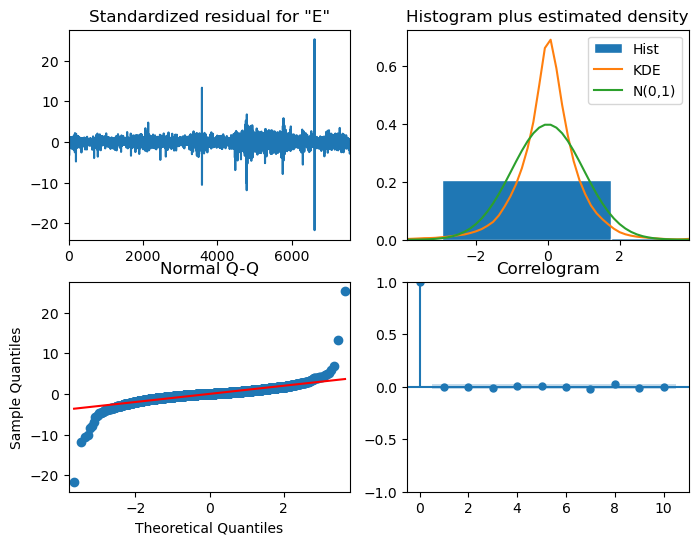

In [10]:
###3.Diagnostics:
# Diagnostic plots of residuals
model_fit.plot_diagnostics(figsize=(8,6))
plt.show()

Residual diagnostic plots were examined to check model adequacy. If residuals are randomly distributed around zero with no clear pattern, the ARIMA model is considered adequate.

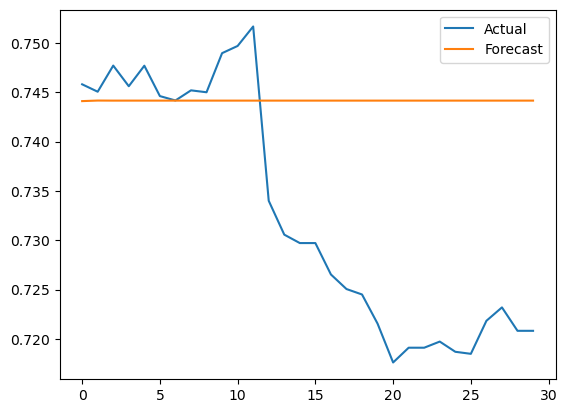

In [11]:
###4.Forecasting:
# Train-test split
train = df['Ex_rate'][:-30]
test = df['Ex_rate'][-30:]
# Fit model
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()
# Forecast next 30 values
forecast = model_fit.forecast(steps=30)
# Plot actual vs forecast
plt.plot(test.values, label='Actual')
plt.plot(forecast.values, label='Forecast')
plt.legend()
plt.show()

The ARIMA model was trained on the training data and used to forecast the next 30 exchange rate values. The forecasted values were plotted against the actual values to compare prediction performance visually.

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100
print("ARIMA MAE:", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA MAPE:", mape)

ARIMA MAE: 0.013494600805800084
ARIMA RMSE: 0.016632177912815297
ARIMA MAPE: 1.8632207485474443


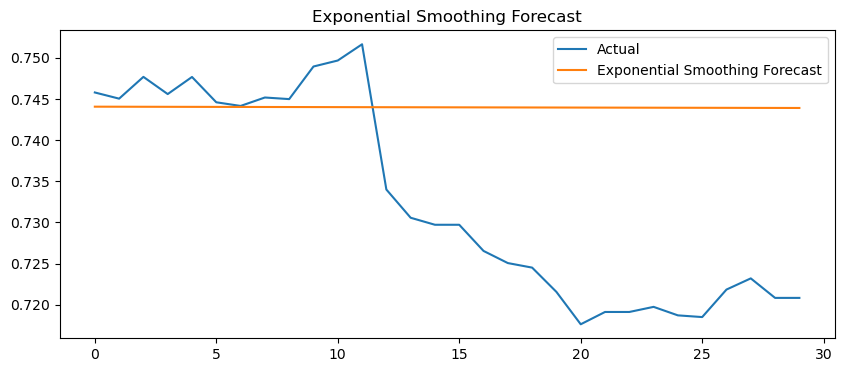

In [16]:
###Exponential Smoothing model:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Fit Exponential Smoothing model
es_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)
es_fit = es_model.fit()
# Forecast next 30 values
es_forecast = es_fit.forecast(steps=30)
# Plot actual vs forecast
plt.figure(figsize=(10,4))
plt.plot(test.values, label='Actual')
plt.plot(es_forecast.values, label='Exponential Smoothing Forecast')
plt.legend()
plt.title('Exponential Smoothing Forecast')
plt.show()

In [17]:
######Part 3:Evaluate Exponential Smoothing:
# Calculate error metrics
es_mae = mean_absolute_error(test, es_forecast)
es_rmse = np.sqrt(
    mean_squared_error(test, es_forecast)
)
es_mape = np.mean(
    np.abs((test - es_forecast) / test)
) * 100
print("Exponential Smoothing MAE:", es_mae)
print("Exponential Smoothing RMSE:", es_rmse)
print("Exponential Smoothing MAPE:", es_mape)

Exponential Smoothing MAE: 0.01342316614852778
Exponential Smoothing RMSE: 0.01649594250463188
Exponential Smoothing MAPE: 1.8531561325102728


In [18]:
###Compare ARIMA and Exponential Smoothing
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [mae, es_mae],
    'RMSE': [rmse, es_rmse],
    'MAPE': [mape, es_mape]
})
print(comparison)

                   Model       MAE      RMSE      MAPE
0                  ARIMA  0.013495  0.016632  1.863221
1  Exponential Smoothing  0.013423  0.016496  1.853156


MAE, RMSE, and MAPE were calculated to evaluate forecast accuracy. Lower values indicate better forecasting performance of the model.

In [19]:
##Parameter optimization using AIC:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
results = []
for trend in [None, 'add', 'mul']:
    try:
        model = ExponentialSmoothing(
            train,
            trend=trend,
            seasonal=None
        )

        fit = model.fit()

        results.append({
            'Trend': trend,
            'AIC': fit.aic
        })
    except:
        pass
results_df = pd.DataFrame(results)
print(results_df)
best_result = results_df.loc[results_df['AIC'].idxmin()]
print("Best Trend:", best_result['Trend'])
print("Best AIC:", best_result['AIC'])

  Trend           AIC
0  None -77320.484553
1   add -77316.492726
2   mul -77316.625309
Best Trend: None
Best AIC: -77320.48455308558


In [20]:
best_trend = best_result['Trend']
best_es_model = ExponentialSmoothing(
    train,
    trend=best_trend,
    seasonal=None
)
best_es_fit = best_es_model.fit()
best_es_forecast = best_es_fit.forecast(steps=30)
print(best_es_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 7558
Model:             ExponentialSmoothing   SSE                              0.272
Optimized:                         True   AIC                         -77320.485
Trend:                             None   BIC                         -77306.624
Seasonal:                          None   AICC                        -77320.479
Seasonal Periods:                  None   Date:                 Mon, 24 Aug 2026
Box-Cox:                          False   Time:                         20:46:47
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8695093                alpha                 True
initial_level              0.78509

In [13]:
####2.Model Comparison:

## 2.Model Comparison:
  ## Performance, Advantages, and Limitations of each model based on the observed results and error metrics:
        ARIMA and Exponential Smoothing were compared using MAE, RMSE, and MAPE. Lower values indicate better forecasting performance. Exponential Smoothing achieved slightly lower values for all three metrics, so it performed slightly better than ARIMA on this dataset. ARIMA is useful for univariate time-series forecasting and can handle non-stationary data through differencing, while Exponential Smoothing is simple and effective for capturing trends. ARIMA may not capture complex patterns or sudden changes effectively, while Exponential Smoothing may also have limitations when the data contains complex patterns or strong seasonality.

In [14]:
####3.Conclusion:

## Conclusion: 
            The exchange rate time series was analyzed using ARIMA and Exponential Smoothing models. The data was preprocessed, stationarity was checked using the ADF test, and the models were evaluated using MAE, RMSE, and MAPE. Based on the results, Exponential Smoothing performed slightly better than ARIMA, as it achieved lower error values. Therefore, Exponential Smoothing was selected as the better-performing model for forecasting the exchange rates in this dataset.